In [110]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os
import pandas as pd
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
import sys
sys.path.append('../utilities')
import utilities as utils


In [111]:

version_in='v1.4'
version_out='v1.7'
# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=["x_0[m]","y_0[m]","z_0[m]","px_0[m]","py_0[m]","pz_0[m]","ekin_0[eV]"]
y_label = 'nC_Ge77'

# Loop through files
x_lf_list=[]
y_lf_list=[]
x_lf_list_sig=[]
file_list = utils.get_all_files(f'/Users/aschuetz/Documents/Analysis/legend/ML/legend-multi-fidelity-surrogate-model/simulation/out/LF/{version_in}/tier2/neutron-sim-LF')
for i in tqdm(range(300)):
    # Construct the file name
    file_in = f'/Users/aschuetz/Documents/Analysis/legend/ML/legend-multi-fidelity-surrogate-model/simulation/out/LF/{version_in}/tier2/neutron-sim-LF-{version_in}-{i:04}-tier2.csv'
    
    try:
        # Read the file
        data_train = pd.read_csv(file_in,nrows=10000)
        
        # Find rows where y_label == 1
        row_lf_sig = data_train.index[(data_train[y_label] == 1)]
        #row_lf_sig = data_train.index[(data_train[y_label] == 1) & (np.sqrt(np.power(data_train[x_labels[1]],2)+np.power(data_train[x_labels[0]],2)) > 0.9)]
        # Extract corresponding rows and append to the list
        x_lf_list_sig.append(data_train.loc[row_lf_sig][x_labels].to_numpy())
        # Find rows where y_label == 1
        row_lf = data_train.index[data_train[y_label] < 5]
        # Extract corresponding rows and append to the list
        x_lf_list.append(data_train[x_labels].to_numpy())
        y_lf_list.append(data_train[y_label].to_numpy())

    except FileNotFoundError:
        print(f"File not found: {file_in}")
    except Exception as e:
        print(f"Error processing file {file_in}: {e}")

# Combine all rows into a single array
x_lf = np.vstack(x_lf_list)
y_lf = np.vstack(y_lf_list)
x_lf_sig = np.vstack(x_lf_list_sig)

# Output the result
print(f"Total rows with y(x) = 1: {x_lf_sig.shape[0]} / {x_lf.shape[0]}")

100%|██████████| 300/300 [00:16<00:00, 18.05it/s]


Total rows with y(x) = 1: 1226 / 3000000


In [112]:


# Output the result
print(f"Total rows with y(x) = 1: {x_lf_sig.shape[0]}")

Total rows with y(x) = 1: 1226


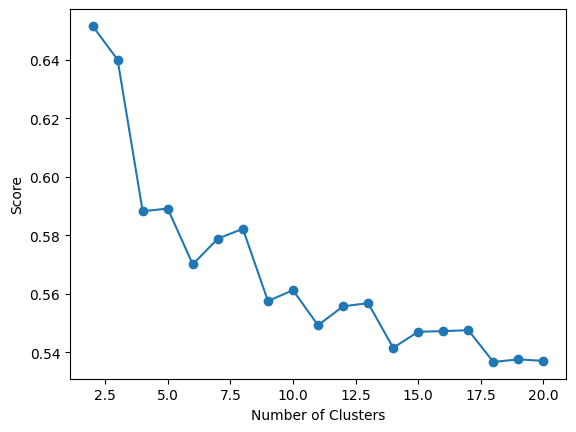

2


In [113]:
from sklearn.metrics import silhouette_score

def silhouette_analysis(X_signal, max_k=10):
    scores = []
    for k in range(2, max_k + 1):  # Silhouette not defined for k=1
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_signal)
        score = silhouette_score(X_signal, kmeans.labels_)
        scores.append(score)
    fig=plt.figure()
    plt.plot(range(2, max_k + 1), scores, marker='o')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')
    #plt.title('Silhouette Analysis')
    plt.show()
    fig.savefig("silhouette_score_LF_10perc_r90.png")
    return range(2, max_k + 1)[np.argmax(scores)]
    

# Example Usage
n_clusters=silhouette_analysis(x_lf_sig,20)
print(n_clusters)

In [114]:
def find_clusters_for_y_equals_1(X_signal, n_clusters=3):
    """
    Finds clusters of x-values where y(x) = 1 using k-means clustering.
    
    Parameters:
    - X: ndarray of shape (n_samples, n_features), input data (5-dimensional features).
    - y: ndarray of shape (n_samples,), binary output (0 or 1).
    - n_clusters: int, number of clusters to find.

    Returns:
    - cluster_centers: ndarray of shape (n_clusters, n_features), the centers of the clusters.
    - labels: ndarray of shape (n_signal_samples,), cluster labels for each signal sample.
    """
    # Filter the data where y(x) = 1
    #X_signal = X[y == 1]
    print(len(X_signal))
    # Scale the data for better clustering performance
    scaler = MinMaxScaler()
    X_signal_scaled = scaler.fit_transform(X_signal)
    
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42,n_init='auto')
    labels = kmeans.fit_predict(X_signal_scaled)
    cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)  # Rescale back to original
    
    return cluster_centers, labels, X_signal



1226
Cluster Centers for y(x) = 1:
[[ 2.83686398e-01  2.47571096e-01 -6.79648232e-01 -2.52425015e-01
   7.39147540e-01  4.62096824e-01  8.84673186e+05]
 [-5.13848944e-01  6.13701923e-01 -6.54904563e-01  4.82099757e-01
  -7.53003165e-01 -1.57604058e-01  7.96122562e+05]
 [ 3.43302846e-01  2.21804359e-02 -6.96409815e-01 -3.14125639e-01
  -7.24484998e-01 -4.74543480e-01  9.75243606e+05]
 [ 1.31088951e-01 -3.23779757e-01 -8.07950237e-01 -2.32885378e-01
   5.06293024e-02  8.90234688e-01  6.42443455e+05]
 [ 4.92023034e-01 -9.68663085e-01 -5.71672050e-01  3.75927249e-01
  -6.68678755e-01  4.40435200e-01  9.04590894e+05]
 [ 1.25300013e-01 -3.86955907e-01 -2.71705316e-01  3.78090742e-01
   6.55945624e-01 -5.22265710e-01  9.49075187e+05]
 [-2.05049596e-01 -5.84898863e-01 -9.35056894e-01  6.23337063e-01
   5.53360376e-01  3.95780976e-01  8.06559899e+05]
 [ 6.46786429e-02 -1.58951752e-01 -9.77371907e-01 -9.14908539e-01
  -3.17678661e-02  9.99184802e-02  9.30957251e+05]
 [ 7.13401529e-01  2.99618428

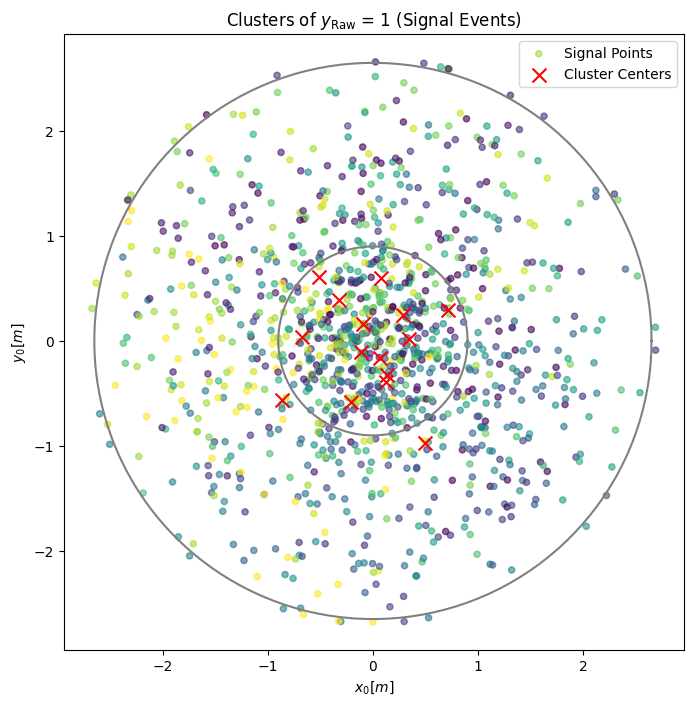

In [120]:
# Example Usage

# Generate synthetic dataset
np.random.seed(42)
n_samples = 1000

# Find clusters for y(x) = 1
n_clusters=15
cluster_centers, labels, X_signal = find_clusters_for_y_equals_1(x_lf_sig, n_clusters=n_clusters)
# Print cluster centers
print(f"Cluster Centers for y(x) = 1:\n{cluster_centers}")
fig = plt.figure(figsize=(8,8))
alpha = np.linspace( 0 , 2 * np.pi , 150 )
r = 2.65
a = r * np.cos( alpha )
b = r * np.sin( alpha )
plt.plot( a, b, color='gray' )

r2 = 0.90
a2 = r2 * np.cos( alpha )
b2 = r2 * np.sin( alpha )
plt.plot( a2, b2, color='gray')
plt.title(r'Clusters of $y_\text{Raw}$ = 1 (Signal Events)')
# Visualize clustering results in 2D (use PCA or select two features)
plt.scatter(X_signal[:, 0], X_signal[:, 1], c=labels, cmap='viridis', s=20,alpha=0.6, label='Signal Points')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='x', s=100, label='Cluster Centers')
plt.xlabel(f'${x_labels[0]}$')
plt.ylabel(f'${x_labels[1]}$')

plt.legend()
plt.show()
fig.savefig('clusters_LF_10perc.png')


In [8]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity


# Step 2: K-Means on Signal Data
def apply_kmeans(X_signal, n_clusters=2):
    """
    Apply k-means clustering to signal data (y=1).

    Parameters:
    - X: ndarray, feature data.
    - n_clusters: int, number of clusters for k-means.

    Returns:
    - kmeans: Fitted KMeans object.
    """

    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X_signal)
    return kmeans

# Step 3: Create Biased Samples
def create_bias_distribution(kmeans, X_signal, n_samples, scale=0.2):
    """
    Generate biased samples using Gaussian noise around k-means cluster centers.

    Parameters:
    - kmeans: Fitted KMeans object.
    - X_signal: ndarray, signal data (y=1).
    - n_samples: int, total number of samples to generate.
    - scale: float, standard deviation of Gaussian noise.

    Returns:
    - biased_samples: ndarray, biased samples.
    """
    cluster_centers = kmeans.cluster_centers_
    samples_per_cluster = np.random.multinomial(n_samples, [1 / len(cluster_centers)] * len(cluster_centers))
    biased_samples = []
    for i, n in enumerate(samples_per_cluster):
        samples = np.random.normal(loc=cluster_centers[i], scale=scale, size=(n, X_signal.shape[1]))
        biased_samples.append(samples)
    return np.vstack(biased_samples)

# Step 4: Compute Importance Weights
def compute_weights(biased_samples, kde_p, kde_q):
    """
    Compute importance weights for biased samples.

    Parameters:
    - biased_samples: ndarray, samples drawn from the bias distribution.
    - kde_p: KernelDensity object for p(x) (target density).
    - kde_q: KernelDensity object for q(x) (biasing distribution).

    Returns:
    - weights: ndarray, normalized importance weights.
    """
    log_p = kde_p.score_samples(biased_samples)
    log_q = kde_q.score_samples(biased_samples)
    print(f"Log p(x) (first 5): {log_p[:5]}")
    print(f"Log q(x) (first 5): {log_q[:5]}")
    weights = np.exp(log_p - log_q)
    weights = np.nan_to_num(weights, nan=0.0, posinf=1.0, neginf=0.0)
    sum_weights = np.sum(weights)
    print(f"Sum of weights: {sum_weights}")
    weights /= np.sum(weights)  # Normalize weights
    plt.hist(log_p, bins=50, alpha=0.5, label='log p(x)')
    plt.hist(log_q, bins=50, alpha=0.5, label='log q(x)')
    plt.legend()
    plt.title("Log Densities of p(x) and q(x)")
    plt.show()
    return weights

# Main


In [ ]:
X_signal = x_lf_sig
# Apply k-means clustering to signal data
kmeans = apply_kmeans(X_signal,2)
# Create biased samples
biased_samples = create_bias_distribution(kmeans, X_signal, n_samples=1000)

/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
# Grid search for optimal bandwidth
#bandwidths = np.logspace(-1, 1, 20)
#grid = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=3)
#grid.fit(x_lf)
#optimal_bandwidth_p = grid.best_params_['bandwidth']

#grid.fit(x_lf_sig)
#optimal_bandwidth_q = grid.best_params_['bandwidth']
#print(optimal_bandwidth_p, optimal_bandwidth_q)

In [ ]:
# Estimate densities for p(x) (target) and q(x) (biasing)
kde_p = KernelDensity(bandwidth=0.8, kernel='gaussian').fit(x_lf)  # Target density

In [ ]:

kde_q = KernelDensity(bandwidth=0.5, kernel='gaussian').fit(biased_samples)  # Biasing density

Log p(x) (first 5): [-247.52050554 -253.08160131 -245.2892121  -255.11841265 -251.9121752 ]
Log q(x) (first 5): [-4.69911536 -5.30076975 -4.8706169  -5.71698662 -4.77120648]
Sum of weights: 4.0846158239395893e-100


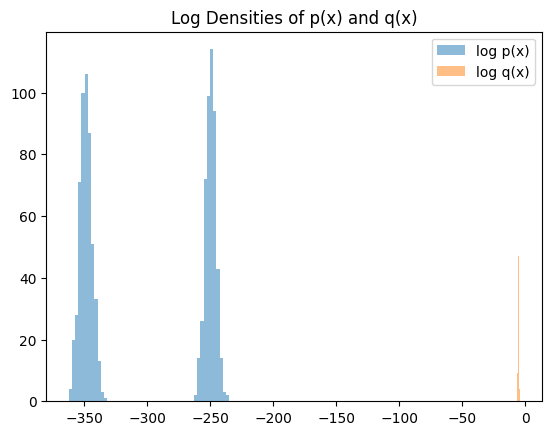

In [ ]:
# Compute importance weights
weights = compute_weights(biased_samples, kde_p, kde_q)

In [ ]:
# Estimate probability of y=1
probability_estimate = np.sum(weights)  # All biased samples assumed to be y=1
print(f"Estimated Probability of y=1: {probability_estimate}")
print(f"Weights (first 5): {weights[:5]}")
print(f"Sum of weights: {np.sum(weights)}")

Estimated Probability of y=1: 1.0000000000000002
Weights (first 5): [8.56759527e-07 6.01175004e-09 9.47064464e-06 1.18901047e-09
 1.13996054e-08]
Sum of weights: 1.0000000000000002


In [ ]:
# Use unnormalized weights for probability estimation
probability_estimate = np.sum(weights * len(biased_samples) / len(x_lf))
print(f"Adjusted Probability of y=1: {probability_estimate}")

Adjusted Probability of y=1: 6.666666666666666e-05


In [ ]:
import matplotlib.pyplot as plt



In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_lf[:, 0], x_lf[:, 1], alpha=0.3, label="Original Data")
plt.scatter(biased_samples[:, 0], biased_samples[:, 1], alpha=0.7, label="Biased Samples")
plt.legend()
plt.title("Coverage of Biased Samples")
plt.show()

KeyboardInterrupt: 

In [ ]:
true_probability = np.mean(y_lf == 1)
print(f"True Probability of y=1: {true_probability}")

True Probability of y=1: 0.00042386666666666665
